# Titanic Survival Prediction using Machine Learning


## Problem Statement

The goal of this project is to develop a classification model that predicts passenger survival on the Titanic dataset using supervised machine learning techniques. The model is trained using historical passenger data and evaluated based on classification accuracy.


## Importing Libraries

In [4]:
import pandas as pd
import seaborn as sns

## Loading DATA

In [5]:
train_data=pd.read_csv("train.csv")
test_data=pd.read_csv("test.csv")

In [6]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## EDA

In [8]:
train_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
test_data.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [10]:
train_data.corr(numeric_only=True).Survived.sort_values(ascending=False)

Survived       1.000000
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Name: Survived, dtype: float64

In [11]:
train_data.drop(['Cabin','Ticket','Name'], axis=1 , inplace = True)
train_data.Sex = train_data['Sex'].map({
    'male' : 0 ,
    'female' : 1
})

In [12]:
test_data.drop(['Cabin','Ticket','Name'], axis=1 , inplace = True)
test_data.Sex = train_data['Sex'].map({
    'male' : 0 ,
    'female' : 1
})

In [13]:
train_data.Age = train_data['Age'].fillna(train_data['Age'].median())
test_data.Age = train_data['Age'].fillna(train_data['Age'].median())

In [14]:
train_data.Embarked = train_data['Embarked'].fillna(train_data['Embarked'].mode()[0])
train_data['Embarked'] = train_data['Embarked'].map({
    'S': 0,
    'C': 1,
    'Q': 2
})

test_data['Embarked'] = test_data['Embarked'].map({
    'S': 0,
    'C': 1,
    'Q': 2
})


In [15]:
test_data.Fare = train_data['Fare'].fillna(train_data['Fare'].median())

## Feature Engineering

In [16]:
train_data['FamilySize'] = train_data['SibSp'] + train_data['Parch'] + 1
test_data['FamilySize'] = test_data['SibSp'] + test_data['Parch'] + 1

In [17]:
train_data['IsAlone'] = (train_data['FamilySize'] == 1).astype(int)
test_data['IsAlone'] = (test_data['FamilySize'] == 1).astype(int)
train_data= train_data.drop(['SibSp','Parch'],axis=1)
test_data= test_data.drop(['SibSp','Parch'],axis=1)
test_data['Sex'] = test_data['Sex'].fillna(train_data['Sex'].mode()[0])


## Training Model

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
x = train_data.drop('Survived', axis=1)
y = train_data['Survived']

In [20]:
x_train,x_test ,y_train,y_test = train_test_split(x,y, test_size=0.3, random_state=42)

In [21]:
from sklearn.linear_model import LogisticRegression
clf=LogisticRegression()

In [22]:
from sklearn.model_selection import GridSearchCV

In [23]:
parameter = {'penalty' : ['l1' , 'l2' , 'elasticnet'], 'C' : [1,2,3,4,5,6,10,20,30,40,50] , 'max_iter':[100,200,300]}

In [24]:
clf_regressor = GridSearchCV(clf, param_grid=parameter, cv= 5 , scoring='accuracy')

In [25]:
clf_regressor.fit(x_train ,y_train)

F:\Conda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
F:\Conda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
F:\C

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [1, 2, 3, 4, 5, 6, 10, 20, 30, 40, 50],
                         'max_iter': [100, 200, 300],
                         'penalty': ['l1', 'l2', 'elasticnet']},
             scoring='accuracy')

In [26]:
print(clf_regressor.best_params_)

{'C': 1, 'max_iter': 300, 'penalty': 'l2'}


In [27]:
print(clf_regressor.best_score_)

0.8041290322580646


In [28]:
y_pred = clf_regressor.predict(x_test)

In [29]:
y_pred

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0])

## Model Evaluation

In [30]:
from sklearn.metrics import accuracy_score,classification_report

In [31]:
print(accuracy_score(y_test,y_pred))

0.8134328358208955


In [32]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       157
           1       0.81      0.72      0.76       111

    accuracy                           0.81       268
   macro avg       0.81      0.80      0.80       268
weighted avg       0.81      0.81      0.81       268



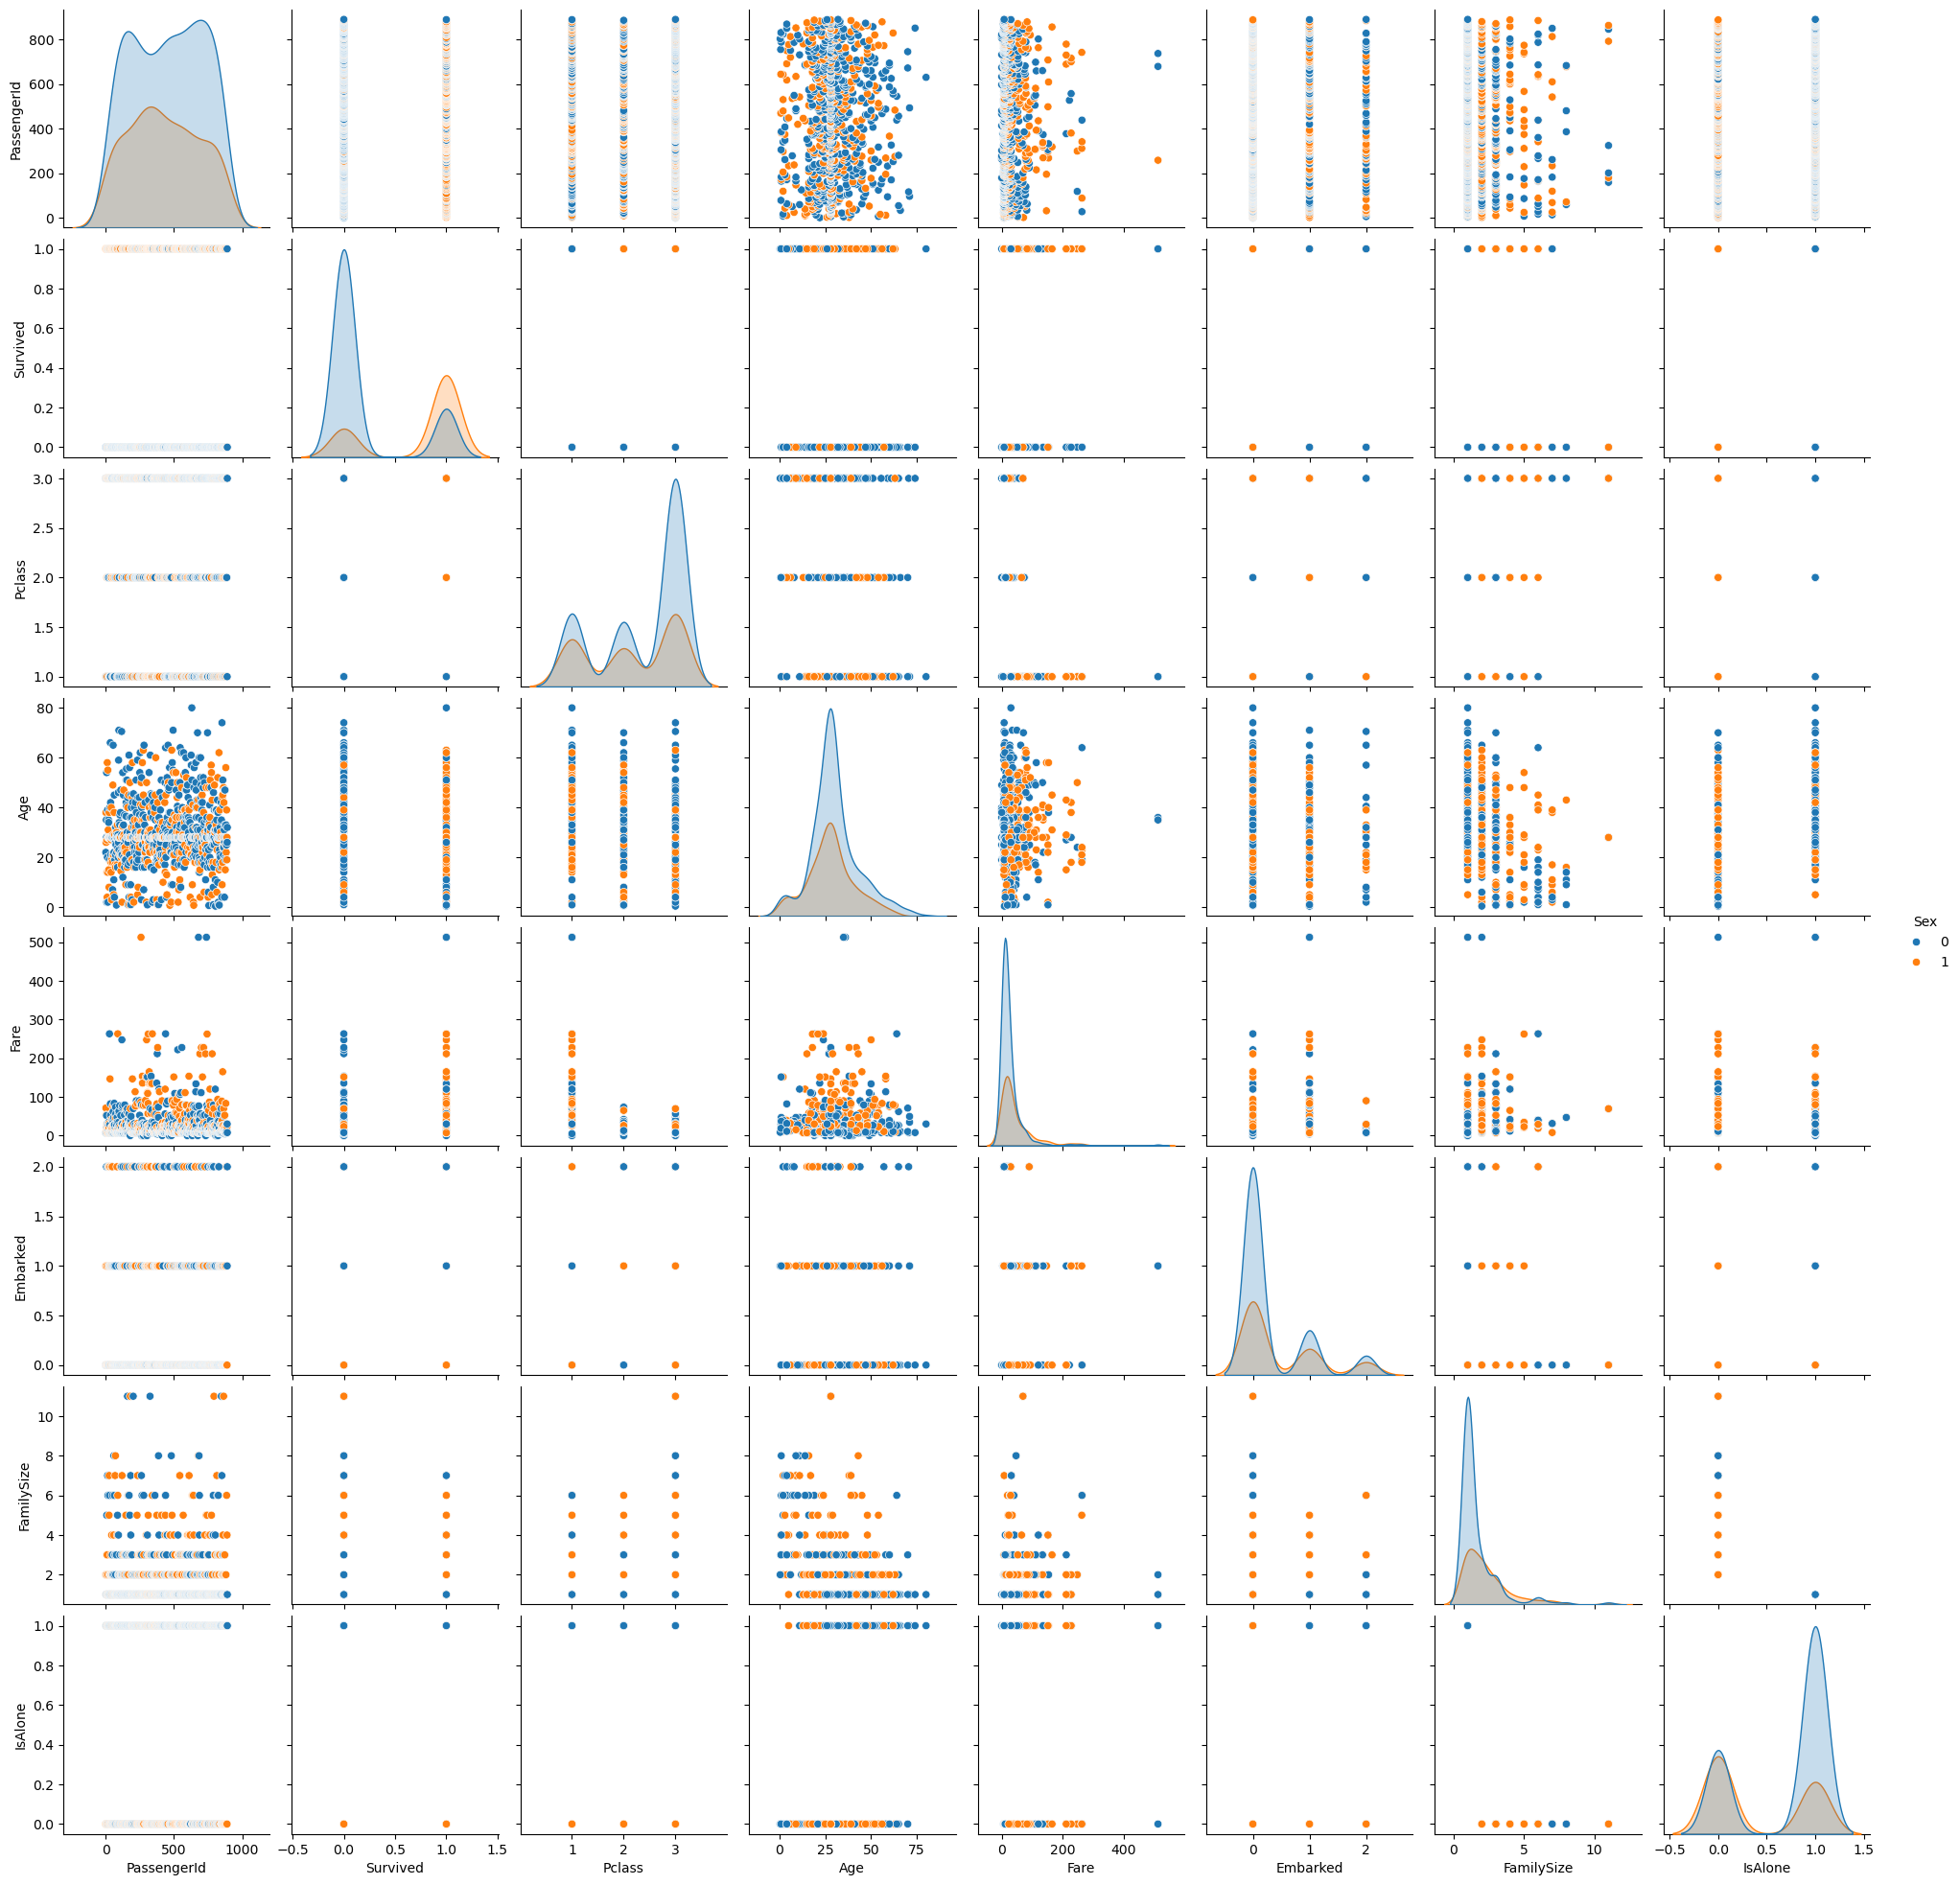

In [33]:
sns.pairplot(train_data , hue= 'Sex')

In [34]:
train_data.corr()

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize,IsAlone
PassengerId,1.000000,-0.005007,-0.035144,-0.042939,0.034212,0.012658,-0.030467,-0.040143,0.057462
Survived,-0.005007,1.000000,-0.338481,0.543351,-0.064910,0.257307,0.106811,0.016639,-0.203367
Pclass,-0.035144,-0.338481,1.000000,-0.131900,-0.339898,-0.549500,0.045702,0.065997,0.135207
Sex,-0.042939,0.543351,-0.131900,1.000000,-0.081163,0.182333,0.116569,0.200988,-0.303646
Age,0.034212,-0.064910,-0.339898,-0.081163,1.000000,0.096688,-0.009165,-0.245619,0.171647
Fare,0.012658,0.257307,-0.549500,0.182333,0.096688,1.000000,0.062142,0.217138,-0.271832
Embarked,-0.030467,0.106811,0.045702,0.116569,-0.009165,0.062142,1.000000,-0.080281,0.017807
FamilySize,-0.040143,0.016639,0.065997,0.200988,-0.245619,0.217138,-0.080281,1.000000,-0.690922
IsAlone,0.057462,-0.203367,0.135207,-0.303646,0.171647,-0.271832,0.017807,-0.690922,1.000000


In [35]:
clf_regressor.fit(x,y)

F:\Conda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
F:\Conda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
F:\C

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [1, 2, 3, 4, 5, 6, 10, 20, 30, 40, 50],
                         'max_iter': [100, 200, 300],
                         'penalty': ['l1', 'l2', 'elasticnet']},
             scoring='accuracy')

In [36]:
test_pred = clf_regressor.predict(test_data)

In [37]:
test_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,

In [38]:
test_df = test_data
test_ids = test_df["PassengerId"]

In [39]:
test_pred = clf_regressor.predict(test_df)

In [40]:
submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Survived": test_pred
})


In [41]:
submission.to_csv("submission.csv", index=False)

## Conclusion

The Logistic Regression model achieved 81% accuracy.
Feature engineering improved performance.
Further improvements can be done using ensemble models.

